# DRAM MESS Benchmark High Level Model
- https://arxiv.org/html/2405.10170v1

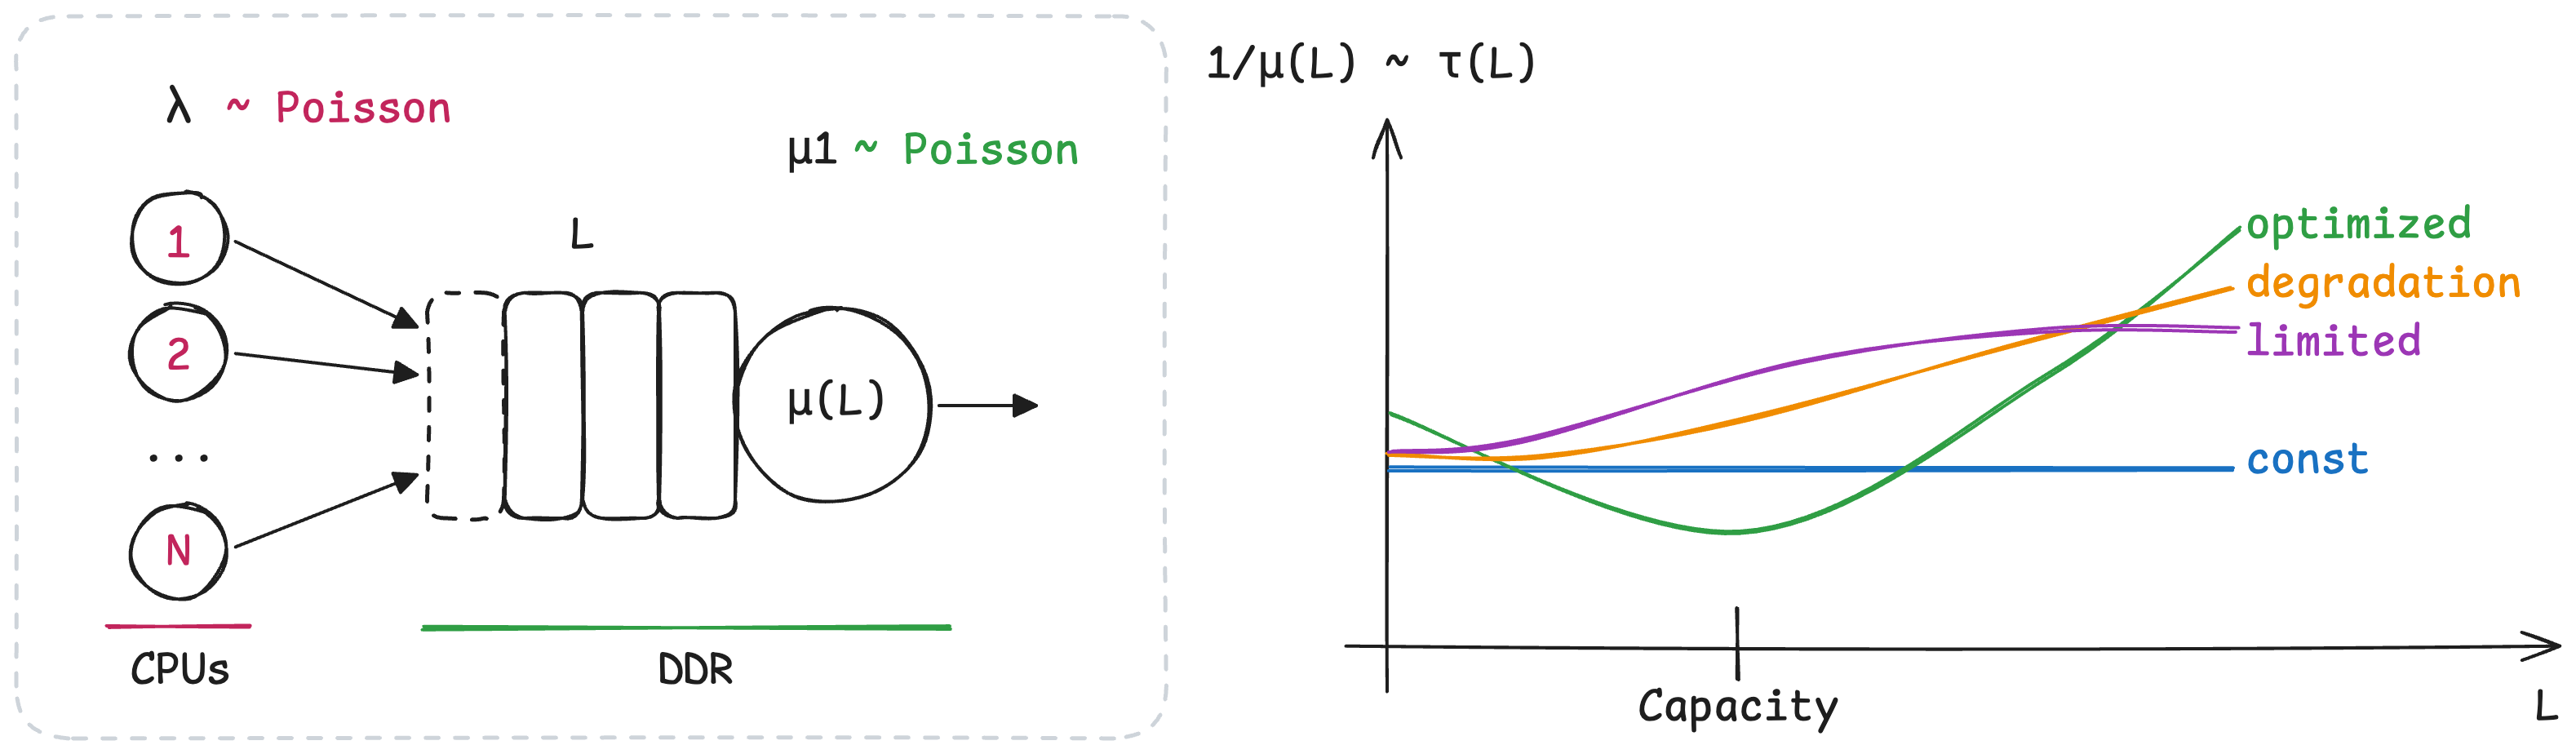

In [1]:
import statistics as stats
from dataclasses import dataclass, field
from itertools import repeat
from multiprocessing.pool import ThreadPool
from typing import Callable, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from simpy import Environment, Resource
from simpy.core import SimTime
from tqdm import tqdm

In [2]:
# Time
SIM_TIME_UNIT: SimTime = 10  # ticks
NS = 1 * SIM_TIME_UNIT
US = 1000 * NS
MS = 1000 * US
SECOND = 1000 * MS

# Frequecny
HZ = 1
KHZ = 1000 * HZ
MHZ = 1000 * KHZ
GHZ = 1000 * MHZ

In [3]:
class Gen:
    def __init__(self):
        self._idx = 0
        self._generators = dict()
        self._orders = dict()

    def new(self, name: str):
        self._idx += 1
        rng = np.random.default_rng(seed=self._idx)
        self._generators[self._idx] = rng
        self._orders[name] = self._idx
        return rng


@dataclass(kw_only=True)
class DramHyperParameters:
    base_latency: SimTime = 70 * NS  # 65-75ns
    multi_channaling: int = 1
    queue_capacity: int = 3000
    queue_capacity_width_ratio = 0.20
    underflow_penalty = 0.9
    overflow_penalty = 1.1
    latency_policy: Literal["const", "degradation", "optimized"] = "const"


@dataclass(kw_only=True)
class CpuHyperParameters:
    frequency: float = 4 * GHZ
    inst_per_loop: int = 1000


@dataclass(kw_only=True)
class HyperParameters:
    running_time: SimTime = 1 * MS
    dram: DramHyperParameters = field(default_factory=DramHyperParameters)
    cpu: CpuHyperParameters = field(default_factory=CpuHyperParameters)

In [4]:
PRESETS = {
    "naive": HyperParameters(),
    "reproduce-hook": HyperParameters(
        dram=DramHyperParameters(latency_policy="optimized")
    ),
    "double-chan-dram": HyperParameters(
        dram=DramHyperParameters(latency_policy="optimized", multi_channaling=2)
    ),
    "slow-dram": HyperParameters(
        dram=DramHyperParameters(
            base_latency=90 * NS,
        )
    ),
    "slow-cpu": HyperParameters(cpu=CpuHyperParameters(frequency=3.3 * GHZ)),
    "heavy-bench": HyperParameters(cpu=CpuHyperParameters(inst_per_loop=350)),
}

In [5]:
class Dram:
    def __init__(
        self, env: Environment, *, lat: Callable[[int], SimTime], channels: int = 1
    ):
        self._env = env
        self._res = Resource(env, capacity=channels)
        self._lat = lat
        self._latencies: list[tuple[int, float]] = []
        self._max_queue = 0
        self._latencies = []

    def read(self, cpu_id: int):
        with self._res.request() as req:
            read_begin = self._env.now
            queue_length = len(self._res.queue)

            self._max_queue = max(self._max_queue, queue_length)
            yield req

            yield self._env.timeout(self._lat(queue_length))
            read_end = self._env.now

        lat = read_end - read_begin
        self._latencies.append((cpu_id, lat))

    @property
    def max_queue_occupancy(self):
        return self._max_queue

    @property
    def latencies(self):
        return self._latencies

    @staticmethod
    def new(env: Environment, hy: DramHyperParameters, rng: np.random.Generator):
        gen_lat = Dram.make_lat_gen(hy.base_latency, rng)
        bounds = Dram.calc_capacity_bounds(
            hy.queue_capacity, hy.queue_capacity_width_ratio
        )

        lat = Dram.make_lat_calc(
            hy.latency_policy,
            gen_lat,
            bounds,
            underflow=hy.underflow_penalty,
            overflow=hy.overflow_penalty,
        )

        dram = Dram(
            env,
            lat=lat,
            channels=hy.multi_channaling,
        )

        return dram

    @staticmethod
    def calc_capacity_bounds(capacity, ratio):
        queue_capacity_width_half = ratio * capacity / 2
        queue_capacity_upper = capacity + queue_capacity_width_half
        queue_capacity_lower = capacity - queue_capacity_width_half
        return queue_capacity_lower, queue_capacity_upper

    @staticmethod
    def make_lat_calc(
        policy: Literal["const", "degradation", "optimized"],
        gen_lat,
        bounds,
        underflow,
        overflow,
    ):
        match policy:
            case "const":

                def const_lat(_queue_length):
                    return gen_lat()

                return const_lat
            case "degradation":

                def degradating_lat(queue_length):
                    lower, upper = bounds
                    latency = gen_lat()
                    if queue_length <= lower:
                        latency *= underflow
                    elif lower < queue_length <= upper:
                        pass
                    elif upper < queue_length:
                        latency *= overflow
                    return latency

                return degradating_lat
            case "optimized":

                def optimized_lat(queue_length):
                    lower, upper = bounds
                    latency = gen_lat()
                    if queue_length <= lower:
                        pass
                    elif lower < queue_length <= upper:
                        latency *= underflow
                    elif upper < queue_length:
                        latency *= overflow
                    return latency

                return optimized_lat

    @staticmethod
    def make_lat_gen(base: SimTime, rng: np.random.Generator):
        # use poisson because it is "like normal" but limited with positive values
        return lambda: rng.poisson(lam=base)

In [6]:
class Cpu:
    def __init__(
        self,
        dram: Dram,
        id,
        rng: np.random.Generator,
        freq: float,
        inst_per_loop: int,
    ):
        self._dram = dram
        self._id = id
        self._time = SECOND / freq * inst_per_loop
        self._rng = rng

    def run(self, env: Environment):
        while True:
            env.process(self._dram.read(self._id))
            yield env.timeout(self._read_delay())

    def _read_delay(self):
        # poisson is like normal but limited with positive values
        return self._rng.poisson(lam=self._time)

In [7]:
def run_simulation(args: tuple[int, HyperParameters]) -> dict:
    n_cpu, hy = args

    gen = Gen()
    env = Environment()
    dram = Dram.new(env, hy.dram, gen.new("DRAM"))
    cpus = [
        Cpu(
            dram=dram,
            id=i,
            rng=gen.new(f"CPU#{i}"),
            freq=hy.cpu.frequency,
            inst_per_loop=hy.cpu.inst_per_loop,
        )
        for i in range(n_cpu)
    ]
    for c in cpus:
        env.process(c.run(env))

    env.run(until=hy.running_time)

    latencies = dram.latencies
    lat_avg = stats.mean(lat for _, lat in latencies) if len(latencies) != 0 else 0.0
    tput = len(latencies) / hy.running_time
    return {
        "n_cpu": n_cpu,
        "run_time": hy.running_time,
        "dram_channels": hy.dram.multi_channaling,
        "lat_avg": lat_avg,
        "tput": tput,
        "max_queue": dram.max_queue_occupancy,
    }

In [8]:
def main():
    cpu_counts = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16, 20]
    preset = PRESETS["reproduce-hook"]
    with ThreadPool() as pool:
        argss = list(zip(cpu_counts, repeat(preset)))
        rows = list(tqdm(pool.imap(run_simulation, argss), total=len(cpu_counts)))

    df = pd.DataFrame(rows)
    return df


df = main()
df

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 47.67it/s]


,n_cpu,run_time,dram_channels,lat_avg,tput,max_queue
0,1,10000000,1,6.998025e+02,0.000400,0
1,2,10000000,1,7.780620e+02,0.000800,1
2,3,10000000,1,9.702100e+02,0.001200,2
3,4,10000000,1,5.351929e+05,0.001429,1714
4,5,10000000,1,1.401431e+06,0.001423,5772
5,6,10000000,1,1.997091e+06,0.001386,10137
6,7,10000000,1,2.426671e+06,0.001371,14289
7,8,10000000,1,2.745342e+06,0.001363,18372
8,9,10000000,1,2.990906e+06,0.001357,22424
9,10,10000000,1,3.186440e+06,0.001354,26462


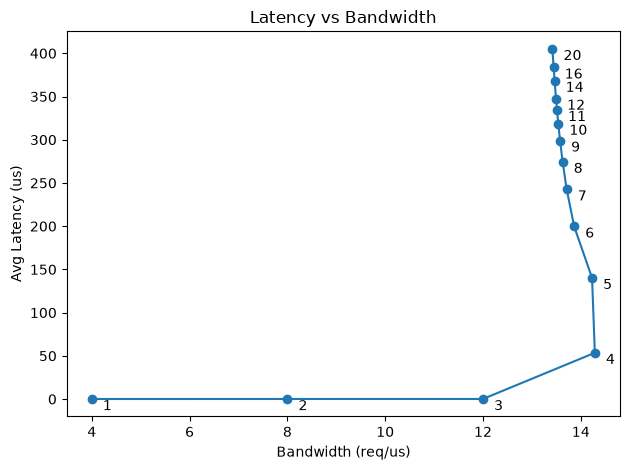

In [9]:
def plot_latency_vs_bandwidth(df: pd.DataFrame, yscale="linear"):
    """Latency vs bandwidth for varying CPU counts."""
    fig, ax = plt.subplots()
    tputs = df["tput"] * US
    lats = df["lat_avg"] / US
    ax.plot(tputs, lats, "o-")
    for i, row in df.iterrows():
        ax.annotate(
            str(int(row["n_cpu"])),
            (tputs[i], lats[i]),
            textcoords="offset points",
            xytext=(8, -8),
        )
    ax.set_title("Latency vs Bandwidth")
    ax.set_xlabel("Bandwidth (req/us)")
    ax.set_ylabel("Avg Latency (us)")
    ax.set_yscale(yscale)
    fig.tight_layout()
    plt.show()


plot_latency_vs_bandwidth(df)  # , "log")

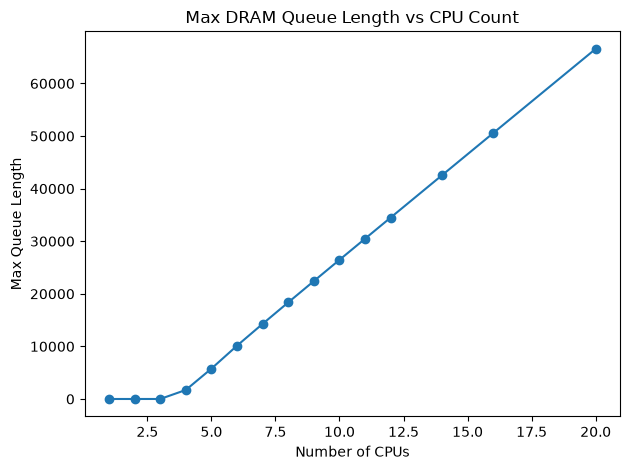

In [10]:
def plot_max_queue_vs_cpus(df: pd.DataFrame):
    """Max queue length vs CPU count."""
    fig, ax = plt.subplots()
    ax.plot(df["n_cpu"], df["max_queue"], "o-")
    ax.set_title("Max DRAM Queue Length vs CPU Count")
    ax.set_xlabel("Number of CPUs")
    ax.set_ylabel("Max Queue Length")
    fig.tight_layout()
    plt.show()


plot_max_queue_vs_cpus(df)